# Hirshfeld density partitioning for AE core embedding

When reconstructing an all-electron core in a frozen plane-wave environment, we need an embedding potential that **removes the absorbing atom’s own local PP** but **keeps the environment’s Hartree/XC**.

CasidaPy’s default recipe (`embed_mode="hirshfeld"`) partitions the converged PW density with UPF free-atom references `ρ̃_B` (`PP_RHOATOM`):

$$
w_A(\mathbf{r}) = \frac{\tilde\rho_A(\mathbf{r})}{\sum_B \tilde\rho_B(\mathbf{r})},\qquad
\rho_\mathrm{act} = w_A\,\rho_\mathrm{tot},\qquad
\rho_\mathrm{env} = (1-w_A)\,\rho_\mathrm{tot}
$$

$$
V_\mathrm{env} = V_\mathrm{ionic} + v_H[\rho_\mathrm{env}] + v_\mathrm{xc}[\rho_\mathrm{env}],\quad
V_\mathrm{ionic} = v_\mathrm{ltot} - V_\mathrm{loc}^\mathrm{QE}(A)
$$

Near the edge nucleus `ρ̃_A` dominates → `w_A → 1` → `ρ_env → 0` (no PP H/XC on the core).  
Far away `ρ̃_A` decays → `ρ_env → ρ_tot` (full environmental H/XC). No `r_damp` knob.

**Gauge (constant shift of \(V_\mathrm{env}\))** — absolute core levels depend on where zero is set:

| `gauge_align` | What it does |
|---|---|
| `"far_field"` (default) | Remapped to **Hirshfeld weight** gauge: zero where \(w_A\) is tiny (environment / non-absorber) |
| `"true_vacuum"` | Zero on the **lowest-\(\rho_\mathrm{tot}\)** grid points (global vacuum; closer to a finite AE cluster) |

Shape of the spectrum (energy *differences*) is unchanged by a constant gauge; absolute \(\varepsilon_{1s}\) / \(\omega_0\) can move.

This notebook walks through **H₂O / O K-edge** on a small QE cell and plots the partition along the O–H bond.

## Prerequisites

- `casidapy`, `qepy`, `dftpy`, `matplotlib`, `scipy`
- Pseudos next to this notebook: `O_ONCV_PBE-1.2.upf`, `H_ONCV_PBE-1.2.upf`
- Amarel: `source setup_env.sh` before starting the kernel (see `h2o_gto_vs_pw.ipynb`)

In [1]:
%matplotlib inline
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from qepy.driver import Driver

from casidapy.embed import (
    ensure_charge_grid,
    ionic_vloc_residual,
    build_ae_embedding_potential,
)
from casidapy.embed import (
    hirshfeld_weights_and_partition,
    hartree_potential_ha,
    xc_potential_ha,
    read_upf_rhoatom,
)

HERE = Path.cwd()
if not (HERE / "O_ONCV_PBE-1.2.upf").is_file():
    # allow running from repo root
    HERE = Path("/projectsn/mp1009_1/am4655/casidapy/tutorials")
assert (HERE / "O_ONCV_PBE-1.2.upf").is_file()
assert (HERE / "H_ONCV_PBE-1.2.upf").is_file()

OUT = HERE / "_hirshfeld_demo_out"
OUT.mkdir(exist_ok=True)
EDGE_O = 0  # O is atom 0
BOHR = 1.8897261258369282  # 1/Å → Bohr

## 1. Quick QE SCF on H₂O

Same 12 Å box / ONCV setup as the GTO vs PW tutorial. QEpy writes `input_tmp.in` in CWD, so we `chdir` into `OUT`.

In [2]:
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "pseudo_dir": f"'{HERE}/'",
        "outdir": f"'{OUT}'",
        "prefix": "'h2o_hf'",
        "verbosity": "'low'",
    },
    "&system": {
        "ibrav": 0,
        "nat": 3,
        "ntyp": 2,
        "ecutwfc": 30.0,
        "ecutrho": 120.0,
        "nbnd": 16,
        "nosym": True,
        "occupations": "'fixed'",
    },
    "&electrons": {"conv_thr": 1.0e-6, "mixing_beta": 0.7},
    "atomic_species": [
        "O  15.9994  O_ONCV_PBE-1.2.upf",
        "H   1.0079  H_ONCV_PBE-1.2.upf",
    ],
    "atomic_positions angstrom": [
        "O  6.000000  6.000000  6.117300",
        "H  6.000000  6.757200  5.530800",
        "H  6.000000  5.242800  5.530800",
    ],
    "cell_parameters angstrom": [
        "12.0  0.0  0.0",
        "0.0  12.0  0.0",
        "0.0  0.0  12.0",
    ],
    "k_points gamma": [],
}

prev = os.getcwd()
try:
    os.chdir(OUT)
    driver = Driver(qe_options=qe_options, logfile=str(OUT / "scf.log"))
    driver.scf()
finally:
    os.chdir(prev)

atoms = driver.get_ase_atoms()
print("symbols:", atoms.get_chemical_symbols())
print("positions (Å):\n", np.round(atoms.get_positions(), 4))

symbols: ['O', 'H', 'H']
positions (Å):
 [[6.     6.     6.1173]
 [6.     6.7572 5.5308]
 [6.     5.2428 5.5308]]


## 2. Hirshfeld weights and density partition

`hirshfeld_weights_and_partition` builds free-atom `ρ̃_B` from each UPF onto the charge grid, then forms `w_A`, `ρ_act`, `ρ_env`.

In [3]:
grid = ensure_charge_grid(driver)
nr = tuple(int(x) for x in grid.nr)
dV = float(grid.dV)  # Bohr³ per grid point

rho_tot, rho_ta, rho_tsum, w_a, rho_act, rho_env = hirshfeld_weights_and_partition(
    driver, EDGE_O, grid
)

def Ne(rho):
    return float(np.sum(rho) * dV)

print(f"grid nr={nr}  dV={dV:.4e} Bohr³")
print(f"∫ ρ_tot  = {Ne(rho_tot):.4f} e")
print(f"∫ ρ_act  = {Ne(rho_act):.4f} e   (Hirshfeld share of O)")
print(f"∫ ρ_env  = {Ne(rho_env):.4f} e")
print(f"∫ ρ̃_O    = {Ne(rho_ta):.4f} e   (UPF free-atom ref on grid)")
print(f"w_O: min={w_a.min():.3e}  max={w_a.max():.4f}  mean={w_a.mean():.4f}")

grid nr=(80, 80, 80)  dV=2.2776e-02 Bohr³
∫ ρ_tot  = 8.0000 e
∫ ρ_act  = 6.2474 e   (Hirshfeld share of O)
∫ ρ_env  = 1.7526 e
∫ ρ̃_O    = 5.9991 e   (UPF free-atom ref on grid)
w_O: min=0.000e+00  max=1.0000  mean=0.0298


### Line cut through O → H1

Sample fields along the bond. Expect `w_O ≈ 1` near O and falling toward H.

saved /projectsn/mp1009_1/am4655/casidapy/tutorials/_hirshfeld_demo_out/hirshfeld_linecut_densities.png


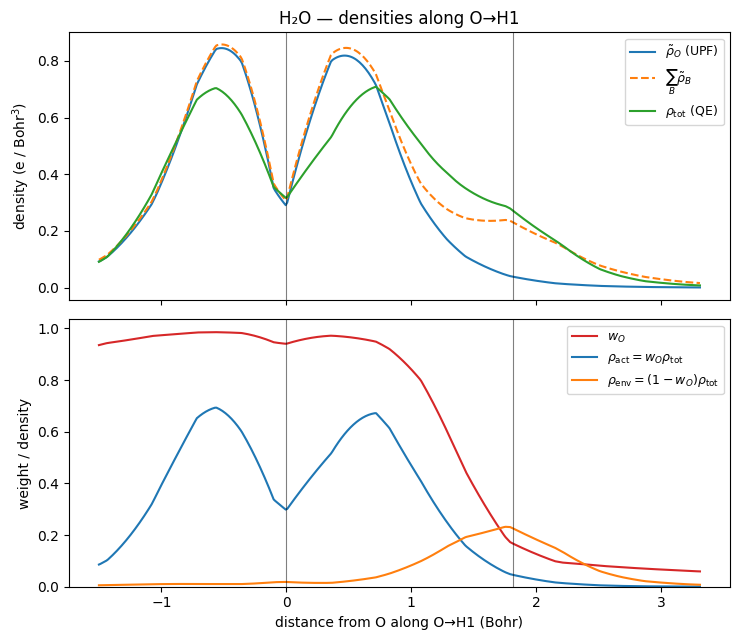

In [4]:
def field_to_interp(field_1d):
    """Fortran-order QE density → RegularGridInterpolator in Cartesian Bohr."""
    f3 = np.asarray(field_1d, float).reshape(nr, order="F")
    # grid.r is (3, n1, n2, n3) with the same F layout when flattened
    x = np.asarray(grid.r[0][:, 0, 0], float)
    y = np.asarray(grid.r[1][0, :, 0], float)
    z = np.asarray(grid.r[2][0, 0, :], float)
    # RegularGridInterpolator wants ascending axes
    return RegularGridInterpolator((x, y, z), f3, bounds_error=False, fill_value=0.0)


pos = atoms.get_positions() * BOHR  # Å → Bohr
o = pos[0]
h1 = pos[1]
direction = h1 - o
bond = np.linalg.norm(direction)
uhat = direction / bond

# extend a bit past O (negative s) and past H
s = np.linspace(-1.5, bond + 1.5, 400)
pts = o[None, :] + s[:, None] * uhat[None, :]

interps = {
    r"$\rho_\mathrm{tot}$": field_to_interp(rho_tot),
    r"$\tilde\rho_O$": field_to_interp(rho_ta),
    r"$\sum \tilde\rho$": field_to_interp(rho_tsum),
    r"$w_O$": field_to_interp(w_a),
    r"$\rho_\mathrm{act}$": field_to_interp(rho_act),
    r"$\rho_\mathrm{env}$": field_to_interp(rho_env),
}
cut = {k: np.asarray(fn(pts), float) for k, fn in interps.items()}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6.5), sharex=True)

ax = axes[0]
ax.plot(s, cut[r"$\tilde\rho_O$"], label=r"$\tilde\rho_O$ (UPF)")
ax.plot(s, cut[r"$\sum \tilde\rho$"], label=r"$\sum_B \tilde\rho_B$", ls="--")
ax.plot(s, cut[r"$\rho_\mathrm{tot}$"], label=r"$\rho_\mathrm{tot}$ (QE)")
ax.axvline(0.0, color="k", lw=0.8, alpha=0.5)
ax.axvline(bond, color="k", lw=0.8, alpha=0.5)
ax.set_ylabel(r"density (e / Bohr$^3$)")
ax.legend(loc="best", fontsize=9)
ax.set_title("H₂O — densities along O→H1")

ax = axes[1]
ax.plot(s, cut[r"$w_O$"], color="C3", label=r"$w_O$")
ax.plot(s, cut[r"$\rho_\mathrm{act}$"], label=r"$\rho_\mathrm{act}=w_O\rho_\mathrm{tot}$")
ax.plot(s, cut[r"$\rho_\mathrm{env}$"], label=r"$\rho_\mathrm{env}=(1-w_O)\rho_\mathrm{tot}$")
ax.axvline(0.0, color="k", lw=0.8, alpha=0.5)
ax.axvline(bond, color="k", lw=0.8, alpha=0.5)
ax.set_xlabel(r"distance from O along O→H1 (Bohr)")
ax.set_ylabel("weight / density")
ax.legend(loc="best", fontsize=9)
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(OUT / "hirshfeld_linecut_densities.png", dpi=150)
print("saved", OUT / "hirshfeld_linecut_densities.png")

## 3. Embedding potential stack

`V_ionic` is the QE local residual after peeling atom A (`vloc_source="qepy"`).  
Environment H/XC are built from `ρ_env` only (NLCC zeroed for that XC evaluation).

We build the default **Hirshfeld weight** gauge (`gauge_align="far_field"`) and compare with **`true_vacuum`**. Meta also reports a nucleus decomposition (`v_*_at_nuc_ha`) — the rigid shift felt by the deep 1s.


meta: {'embed_mode': 'hirshfeld', 'vloc_source': 'qepy', 'gauge_align': 'hirshfeld', 'gauge_shift_ha': -0.00538904641280775}
saved /projectsn/mp1009_1/am4655/casidapy/tutorials/_hirshfeld_demo_out/hirshfeld_linecut_potentials.png


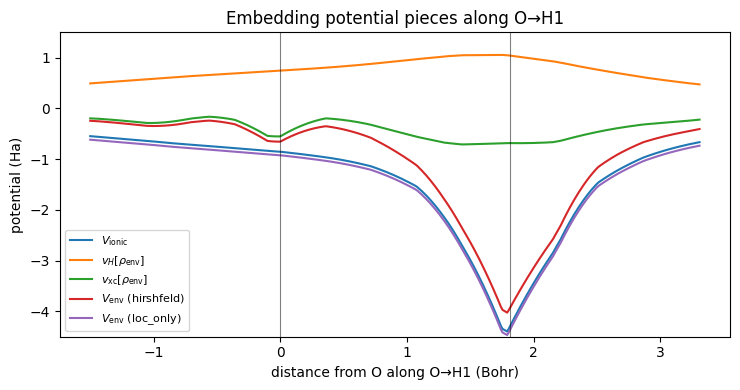

In [6]:
_, v_ionic = ionic_vloc_residual(
    driver, EDGE_O, grid, upf_path=str(HERE / "O_ONCV_PBE-1.2.upf"), vloc_source="qepy"
)
v_h_env = hartree_potential_ha(driver, rho_env)
v_xc_env = xc_potential_ha(driver, rho_env, zero_nlcc=True)

upf_o = str(HERE / "O_ONCV_PBE-1.2.upf")

# Default production V_env (far_field → Hirshfeld weight gauge)
v_env, _, meta = build_ae_embedding_potential(
    driver,
    EDGE_O,
    upf_path=upf_o,
    embed_mode="hirshfeld",
    vloc_source="qepy",
    gauge_align="far_field",
    verbose=True,
)

# Same partition, true-vacuum gauge (lowest-ρ_tot reference)
v_env_tv, _, meta_tv = build_ae_embedding_potential(
    driver,
    EDGE_O,
    upf_path=upf_o,
    embed_mode="hirshfeld",
    vloc_source="qepy",
    gauge_align="true_vacuum",
    verbose=True,
)

_keys = (
    "embed_mode",
    "vloc_source",
    "gauge_align",
    "gauge_shift_ha",
    "v_env_at_nuc_ha",
    "v_ionic_at_nuc_ha",
    "v_h_at_nuc_ha",
    "v_xc_at_nuc_ha",
)
print("meta (weight gauge):", {k: meta[k] for k in _keys if k in meta})
print("meta (true_vacuum): ", {k: meta_tv[k] for k in _keys if k in meta_tv})

v_loc_only, _, meta_lo = build_ae_embedding_potential(
    driver,
    EDGE_O,
    upf_path=upf_o,
    embed_mode="loc_only",
    vloc_source="qepy",
    verbose=False,
)

cut_v = {
    r"$V_\mathrm{ionic}$": np.asarray(field_to_interp(v_ionic)(pts), float),
    r"$v_H[\rho_\mathrm{env}]$": np.asarray(field_to_interp(v_h_env)(pts), float),
    r"$v_\mathrm{xc}[\rho_\mathrm{env}]$": np.asarray(field_to_interp(v_xc_env)(pts), float),
    r"$V_\mathrm{env}$ (hirshfeld weight)": np.asarray(field_to_interp(v_env)(pts), float),
    r"$V_\mathrm{env}$ (true_vacuum)": np.asarray(field_to_interp(v_env_tv)(pts), float),
    r"$V_\mathrm{env}$ (loc_only)": np.asarray(field_to_interp(v_loc_only)(pts), float),
}

fig, ax = plt.subplots(figsize=(7.5, 4.0))
for label, y in cut_v.items():
    ax.plot(s, y, label=label)
ax.axvline(0.0, color="k", lw=0.8, alpha=0.5)
ax.axvline(bond, color="k", lw=0.8, alpha=0.5)
ax.set_xlabel(r"distance from O along O→H1 (Bohr)")
ax.set_ylabel("potential (Ha)")
ax.set_title("Embedding potential pieces along O→H1")
ax.legend(loc="best", fontsize=8)
ax.set_ylim(-4.5, 1.5)  # zoom; ionic near other nuclei is deep
fig.tight_layout()
fig.savefig(OUT / "hirshfeld_linecut_potentials.png", dpi=150)
print("saved", OUT / "hirshfeld_linecut_potentials.png")


## 4. UPF free-atom `ρ̃(r)` (why the core weight is soft)

ONCV `PP_RHOATOM` is a **valence** free-atom density — it does not carry a true 1s cusp. The weight is still ~1 near O because `ρ̃_O ≫ ρ̃_H` there, but the ionic peel (`vltot − V_loc(A)`) is what removes the absorbing atom’s local PP correctly.

saved /projectsn/mp1009_1/am4655/casidapy/tutorials/_hirshfeld_demo_out/upf_rhoatom_radial.png


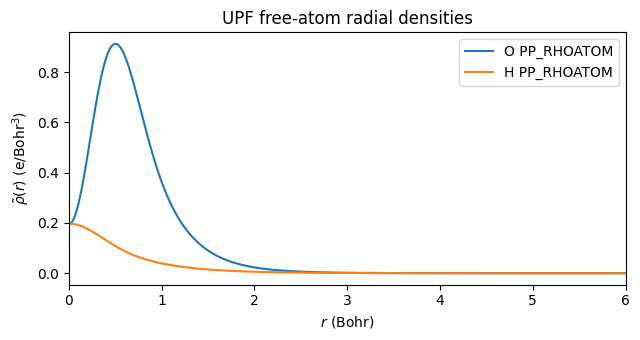

In [7]:
r_o, rho_o = read_upf_rhoatom(HERE / "O_ONCV_PBE-1.2.upf")
r_h, rho_h = read_upf_rhoatom(HERE / "H_ONCV_PBE-1.2.upf")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(r_o, rho_o, label="O PP_RHOATOM")
ax.plot(r_h, rho_h, label="H PP_RHOATOM")
ax.set_xlim(0, 6)
ax.set_xlabel(r"$r$ (Bohr)")
ax.set_ylabel(r"$\tilde\rho(r)$ (e/Bohr$^3$)")
ax.set_title("UPF free-atom radial densities")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "upf_rhoatom_radial.png", dpi=150)
print("saved", OUT / "upf_rhoatom_radial.png")

## 5. Optional — reconstruct O 1s in `V_env`

One-atom AE SCF in the frozen embedding (formal O²⁻ / `ae_electrons="atomic"`). Compare `loc_only`, default Hirshfeld **weight** gauge, and Hirshfeld **`true_vacuum`** gauge — the last two differ by a near-constant shift of $V_\mathrm{env}$.


In [8]:
from casidapy.xas import scf_ae_core_semicore

pos_o_ang = atoms.get_positions()[EDGE_O]
upf_o = str(HERE / "O_ONCV_PBE-1.2.upf")

# (label, embed_mode, gauge_align)
cases = [
    ("loc_only", "loc_only", "far_field"),
    ("hirshfeld/weight", "hirshfeld", "far_field"),
    ("hirshfeld/true_vacuum", "hirshfeld", "true_vacuum"),
]

rows = []
for label, mode, gauge in cases:
    v, g, m = build_ae_embedding_potential(
        driver,
        EDGE_O,
        upf_path=upf_o,
        embed_mode=mode,
        vloc_source="qepy",
        gauge_align=gauge,
        verbose=False,
    )
    mf = scf_ae_core_semicore(
        v,
        g,
        "O",
        pos_o_ang,
        basis="def2-svp",
        xc="pbe",
        ae_electrons="atomic",
        z_valence=6.0,
        verbose=False,
    )
    eps = float(mf.mo_energy[0])
    rows.append((label, eps, m))
    print(
        f"{label:22s}  ε_1s = {eps:.6f} Ha  ({eps*27.2114:.2f} eV)  "
        f"gauge_align={m.get('gauge_align')}  shift={m.get('gauge_shift_ha')}  "
        f"V_env(nuc)={m.get('v_env_at_nuc_ha')}"
    )

print(f"Δε (weight − loc_only)      = {(rows[1][1]-rows[0][1])*27.2114:+.3f} eV")
print(f"Δε (true_vacuum − weight)   = {(rows[2][1]-rows[1][1])*27.2114:+.3f} eV")


loc_only    ε_1s = -18.991419 Ha  (-516.78 eV)  gauge=0.06986557924553818
hirshfeld   ε_1s = -18.748471 Ha  (-510.17 eV)  gauge=-0.00538904641280775
Δε (hirshfeld − loc_only) = +6.611 eV


In [9]:
driver.stop()
print("done")

done
